<a href="https://colab.research.google.com/github/prasad2154/NewVision/blob/main/Machine_learning/crossValidation_hyper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

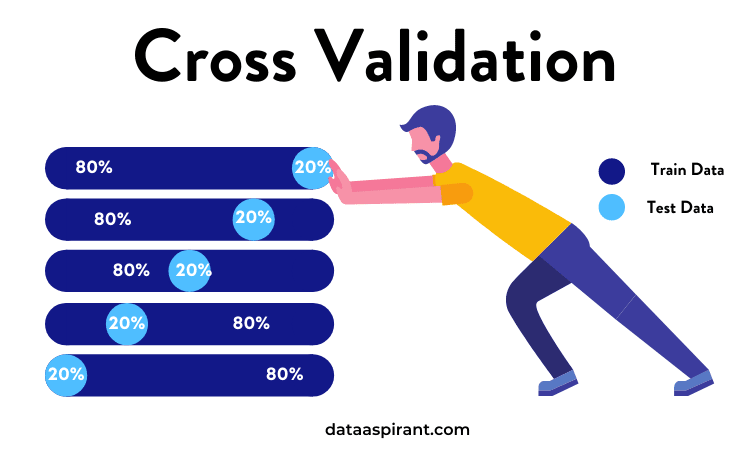

**Cross-validation (CV)** is a statistical resampling technique used to evaluate how well a machine learning model generalizes to unseen data. Instead of relying on a single train-test split, CV repeatedly partitions the dataset into training and validation subsets, trains the model on one subset, and evaluates it on another.
This process reduces the risk of overfitting and provides a more reliable performance estimate.


**Advantages:**

Better performance estimation than a single split.

Efficient use of data — every sample is used for training and validation.

Reduced overfitting risk by testing on multiple unseen subsets.

https://dataaspirant.com/cross-validation/

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
data = "https://raw.githubusercontent.com/hakimyameen/Datasets/refs/heads/main/PimaIndiansDiabetes.csv"

In [ ]:
df = pd.read_csv(data)
df[:2]

,TimesPregnant,GlucoseConcentration,BloodPrs,SkinThickness,Serum,BMI,DiabetesFunct,Age,Class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


In [ ]:
df['Class'].value_counts()

,count
Class,
0,500
1,268


In [ ]:
 #1 2 3 4  ---> discrete value

 #1 1.1 1.2 1.5 1.8 2 2.5 2.2 2.4 2.7 4. --> continueous

In [ ]:
# check summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TimesPregnant         768 non-null    int64  
 1   GlucoseConcentration  768 non-null    int64  
 2   BloodPrs              768 non-null    int64  
 3   SkinThickness         768 non-null    int64  
 4   Serum                 768 non-null    int64  
 5   BMI                   768 non-null    float64
 6   DiabetesFunct         768 non-null    float64
 7   Age                   768 non-null    int64  
 8   Class                 768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# data preparation input and output

X = df.iloc[:,:-1]  # skip last column which is our target column
X[:1]

,TimesPregnant,GlucoseConcentration,BloodPrs,SkinThickness,Serum,BMI,DiabetesFunct,Age
0,6,148,72,35,0,33.6,0.627,50


In [ ]:
y = df['Class']  # target column/output column
y[:1]

,Class
0,1


In [ ]:
# split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
X_train[:5]

,TimesPregnant,GlucoseConcentration,BloodPrs,SkinThickness,Serum,BMI,DiabetesFunct,Age
464,10,115,98,0,0,24.0,1.022,34
223,7,142,60,33,190,28.8,0.687,61
393,4,116,72,12,87,22.1,0.463,37
766,1,126,60,0,0,30.1,0.349,47
570,3,78,70,0,0,32.5,0.270,39


In [ ]:
# Training
model = LogisticRegression()
model

LogisticRegression()

In [ ]:
model.fit(X_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# prediction
y_pred = model.predict(X_test)
y_pred[:5]  # predcited result

array([0, 0, 0, 0, 1])

In [ ]:
y_test[:5].values  # actual result

array([0, 0, 0, 0, 0])

In [ ]:
len(y_test)

254

In [ ]:
# accuracy score
accuracy_score(y_test,y_pred)*100

74.80314960629921

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       168
           1       0.63      0.63      0.63        86

    accuracy                           0.75       254
   macro avg       0.72      0.72      0.72       254
weighted avg       0.75      0.75      0.75       254



### **Assignment: Apply SMOTE on above data and then check classification report**

In [ ]:
#import  cross validation
from sklearn.model_selection import cross_val_score

In [ ]:
#cross_val_score(Algorithm,input,output,fold)

In [ ]:
# 1000
# Cross validation- 80-20%
# 800(Train)|200(Test)--> 1 fold

# 1000/5= 200---> TEST records

# 200 200 200 200 [200]
# 200 200 200 [200] 200
# 200 200 [200] 200 200
# 200 [200] 200 200 200
# [200] 200 200 200 200

In [ ]:
model.score(X_train,y_train)  # training data score

0.7801556420233463

In [ ]:
import warnings
warnings.filterwarnings('ignore')
# cross val score gives "accuracy" metric by default
cross_val_score(model,X_train,y_train)  # default cv = 5

array([0.80582524, 0.70873786, 0.81553398, 0.72815534, 0.75490196])

In [ ]:
# I want to use another scoring function- precision, recall, F1_score
cross_val_score(model,X_train,y_train,scoring='precision')

array([0.76666667, 0.59375   , 0.82142857, 0.66666667, 0.68965517])

In [ ]:
# if the algorithm is regression and target is contineous then it chooses Kfold and metrics is: r2 score
# if the algorithm is classification and target var is categorical then it uses StratifiedKFold
# and metric is: accuracy

In [ ]:
# check average accuracy
cross_val_score(model,X_train,y_train,cv=5).mean()

np.float64(0.7626308775937559)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

cross_val_score(KNeighborsClassifier(n_neighbors=5),X_train,y_train,cv=5).mean()

np.float64(0.7023415191319247)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

cross_val_score(DecisionTreeClassifier(criterion='entropy',max_depth=4),X_train,y_train,cv=5).mean()

np.float64(0.7684561203122026)

In [ ]:
from sklearn.svm import SVC

cross_val_score(SVC(),X_train,y_train,cv=5).mean()

np.float64(0.7470968970112317)

In [ ]:
# Apply RandomForest
# SME- Subject Matter Expert
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TimesPregnant,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
GlucoseConcentration,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPrs,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Serum,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesFunct,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Class,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [ ]:
sum(df['GlucoseConcentration']==0)

5

# **HyperParameter Tuning**

https://www.tutorialspoint.com/article/hyperparameter-tuning-in-machine-learning

https://www.appliedaicourse.com/blog/hyperparameter-tuning-in-machine-learning/

https://medium.com/@aditib259/a-comprehensive-guide-to-hyperparameter-tuning-in-machine-learning-dd9bb8072d02


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
cross_val_score(RandomForestClassifier(),X_train,y_train,cv=5).mean()

np.float64(0.7645916619074814)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters
param_grid = {
    'n_estimators': [10, 20,40, 50, 100, 200],
    'max_depth': [None, 8,10, 20],
    'min_samples_split': [2, 4, 5,7, 10],
   "criterion": ["gini", "entropy"],
}

# Initialize model
rf = RandomForestClassifier()

# Perform Grid Search
# GridSearchCV(model,param_grid,cv)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)  # learning

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 7, 'n_estimators': 40}
Best Score: 0.7938130592042641


In [ ]:
rf_new = grid_search.best_estimator_
rf_new  # new model with hyperParameterTuning

RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_split=7,
                       n_estimators=40)

In [ ]:
cross_val_score(rf_new,X_train,y_train,cv=5).mean()

np.float64(0.7548258138206739)

In [ ]:
# Logistic Regression Parameter grid
param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'] # 'liblinear' supports 'l1' and 'l2', 'saga' supports 'l1', 'l2', 'elasticnet'
}

In [ ]:
print(param_grid_lr)

## **Assignment- Use RandomizedSearchCV over the same data**

In [ ]:
# Perform Grid Search
# GridSearchCV(model,param_grid,cv)
grid_search = GridSearchCV(LogisticRegression(), param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

### 1. Using a `for` loop

In [ ]:
num = 29 # Example number
is_prime_for = True

# Prime numbers are greater than 1
if num <= 1:
    is_prime_for = False
elif num <= 3:
    is_prime_for = True
else:
    # Check for factors from 2 up to num - 1
    for i in range(2, num):
        if (num % i) == 0:
            is_prime_for = False
            break

if is_prime_for:
    print(f"{num} is a prime number (using for loop)")
else:
    print(f"{num} is not a prime number (using for loop)")


### 2. Using a `while` loop

In [ ]:
num = 31 # Example number
is_prime_while = True

if num <= 1:
    is_prime_while = False
elif num <= 3:
    is_prime_while = True
else:
    i = 2
    # Check for factors from 2 up to num - 1
    while i < num:
        if (num % i) == 0:
            is_prime_while = False
            break
        i += 1

if is_prime_while:
    print(f"{num} is a prime number (using while loop)")
else:
    print(f"{num} is not a prime number (using while loop)")


### 3. Using a function

In [ ]:
def is_prime_function(n):
    if n <= 1:
        return False
    if n <= 3:
        return True
    # This is an optimization: check only up to the square root of n
    # Also, check only odd numbers after 2 and 3
    if n % 2 == 0 or n % 3 == 0:
        return False
    i = 5
    while i * i <= n:
        if n % i == 0 or n % (i + 2) == 0:
            return False
        i += 6
    return True

# Test the function
print(f"Is 17 prime? {is_prime_function(17)}")
print(f"Is 4 prime? {is_prime_function(4)}")
print(f"Is 2 prime? {is_prime_function(2)}")
print(f"Is 1 prime? {is_prime_function(1)}")
print(f"Is 29 prime? {is_prime_function(29)}")


### 4. Using list comprehension (to find divisors)

In [ ]:
num = 37 # Example number

# Find divisors using list comprehension
divisors = [i for i in range(1, num + 1) if num % i == 0]

is_prime_lc = len(divisors) == 2 and num > 1 # A prime number has exactly two divisors: 1 and itself

if is_prime_lc:
    print(f"{num} is a prime number (using list comprehension to find divisors)")
else:
    print(f"{num} is not a prime number (using list comprehension to find divisors)")
print(f"Divisors of {num}: {divisors}")


### 5. Using `math` module for efficiency (optimizing the function approach)

In [ ]:
import math

def is_prime_optimized(n):
    if n <= 1:
        return False
    if n <= 3:
        return True
    if n % 2 == 0 or n % 3 == 0:
        return False

    # Check only up to the square root of n
    # Using math.isqrt for integer square root
    i = 5
    while i <= math.isqrt(n):
        if n % i == 0 or n % (i + 2) == 0:
            return False
        i += 6
    return True

# Test the optimized function
print(f"Is 101 prime? {is_prime_optimized(101)}")
print(f"Is 99 prime? {is_prime_optimized(99)}")
print(f"Is 7 prime? {is_prime_optimized(7)}")
